# Homogeneous anisotropic soft-tissue remodeling

This notebook studies a two-dimensional homogeneous soft tissue reinforced by one undirected fiber family. The deformation gradient is prescribed, while the fiber orientation and structural-order parameter evolve in response to a mechanical stimulus.

The computational loop is

\[
\text{structure}
\longrightarrow
\text{mechanical response}
\longrightarrow
\text{mechanical stimulus}
\longrightarrow
\text{remodeled structure}.
\]

## Objectives

1. Define a reproducible parameter set.
2. Inspect the constitutive response at finite strain.
3. Verify the analytical first Piola stress numerically.
4. Confirm that isotropic stretch does not impose an artificial remodeling direction.
5. Run the reference uniaxial-remodeling simulation.
6. Check physical bounds and time-step sensitivity.
7. Export the time history for later analysis.

> **Scope.** Version 0.1 prescribes a homogeneous deformation gradient. It is not yet a finite-element boundary-value solver, and its evolution laws are phenomenological baseline laws rather than universal biological relations.

## 1. Reproducible environment

The next cell locates the repository root automatically. The notebook therefore works from either the repository root or the `notebooks/` directory. During package development, the local `src/` directory is added to `sys.path`.

In [1]:
from __future__ import annotations

import sys
from dataclasses import asdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


def find_repository_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "pyproject.toml").exists() and (candidate / "src").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


REPOSITORY_ROOT = find_repository_root(Path.cwd().resolve())
SOURCE_DIRECTORY = REPOSITORY_ROOT / "src"
if str(SOURCE_DIRECTORY) not in sys.path:
    sys.path.insert(0, str(SOURCE_DIRECTORY))

from anisotropic_remodeling import (  # noqa: E402
    MaterialParameters,
    RemodelingParameters,
    SimulationConfig,
    angle_to_vector,
    cauchy_stress,
    directional_stretch_stimulus,
    first_piola_stress,
    hill_activation,
    principal_stretch_direction,
    run_homogeneous_remodeling,
    strain_energy_density,
    update_fiber_orientation,
)
from anisotropic_remodeling.loading import area_preserving_uniaxial_deformation  # noqa: E402
from anisotropic_remodeling.material import invariants  # noqa: E402
from anisotropic_remodeling.orientation import (  # noqa: E402
    nematic_angle_difference,
    vector_to_angle,
)

np.set_printoptions(precision=6, suppress=True)

print(f"Repository root: {REPOSITORY_ROOT}")
print(f"NumPy version: {np.__version__}")

Repository root: D:\Anisotropic-Soft-Tissue-Remodeling
NumPy version: 1.24.3


## 2. Model definition

The kinematics are defined by

\[
J=\det\mathbf F>0,\qquad
\mathbf C=\mathbf F^\mathsf{T}\mathbf F,\qquad
I_1=\operatorname{tr}\mathbf C,\qquad
I_4=\mathbf a_0\cdot\mathbf C\mathbf a_0.
\]

The strain-energy density is split into matrix and fiber contributions:

\[
\psi=\psi_m+\psi_f,
\]

\[
\psi_m=
\frac{\mu}{2}\left(I_1-2-2\ln J\right)
+\frac{\kappa}{2}(\ln J)^2,
\]

\[
\psi_f=
\beta\frac{k_1}{2k_2}
\left[
\exp\left(k_2\langle I_4-1\rangle_+^2\right)-1
\right].
\]

Here, \(\mathbf a_0\) is a unit fiber direction in the reference configuration and \(\beta\in[0,1]\) is the structural-order parameter. The positive-part operator makes the fiber family active only in extension.

The remodeling stimulus is

\[
S=\left|\ln\lambda_{\max}-\ln\lambda_{\min}\right|,
\]

which vanishes under isotropic stretch. Structural order relaxes toward a bounded Hill-law equilibrium, while the nematic fiber direction relaxes toward the direction of maximum principal stretch.

In [2]:
config = SimulationConfig(
    total_time=40.0,
    dt=0.05,
    ramp_duration=8.0,
    maximum_stretch=1.25,
    initial_fiber_angle_deg=60.0,
    initial_beta=0.10,
)

material = MaterialParameters(mu=10.0, kappa=1000.0, k1=2.0, k2=5.0)

remodeling = RemodelingParameters(
    orientation_rate=0.25,
    order_rate=0.15,
    beta_min=0.10,
    beta_max=1.00,
    half_saturation=0.20,
    hill_exponent=2.0,
)

for title, values in (
    ("Simulation configuration", asdict(config)),
    ("Material parameters", asdict(material)),
    ("Remodeling parameters", asdict(remodeling)),
):
    print(title)
    for name, value in values.items():
        print(f"  {name}: {value}")
    print()

Simulation configuration
  total_time: 40.0
  dt: 0.05
  ramp_duration: 8.0
  maximum_stretch: 1.25
  initial_fiber_angle_deg: 60.0
  initial_beta: 0.1

Material parameters
  mu: 10.0
  kappa: 1000.0
  k1: 2.0
  k2: 5.0

Remodeling parameters
  orientation_rate: 0.25
  order_rate: 0.15
  beta_min: 0.1
  beta_max: 1.0
  half_saturation: 0.2
  hill_exponent: 2.0



## 3. Constitutive response at the maximum prescribed stretch

In [3]:
F_max = area_preserving_uniaxial_deformation(
    config.ramp_duration,
    maximum_stretch=config.maximum_stretch,
    ramp_duration=config.ramp_duration,
)
a0_initial = angle_to_vector(np.deg2rad(config.initial_fiber_angle_deg))

J, I1, I4 = invariants(F_max, a0_initial)
psi = strain_energy_density(F_max, a0_initial, config.initial_beta, material)
P = first_piola_stress(F_max, a0_initial, config.initial_beta, material)
sigma = cauchy_stress(F_max, a0_initial, config.initial_beta, material)
stimulus = directional_stretch_stimulus(F_max)

print("F =")
print(F_max)
print(f"\nJ   = {float(J):.6f}")
print(f"I1  = {float(I1):.6f}")
print(f"I4  = {float(I4):.6f}")
print(f"S   = {float(stimulus):.6f}")
print(f"psi = {float(psi):.6f}")
print("\nFirst Piola stress P =")
print(P)
print("\nCauchy stress sigma =")
print(sigma)

F =
[[1.25 0.  ]
 [0.   0.8 ]]

J   = 1.000000
I1  = 2.202500
I4  = 0.870625
S   = 0.446287
psi = 1.012500

First Piola stress P =
[[ 4.5  0. ]
 [ 0.  -4.5]]

Cauchy stress sigma =
[[ 5.625  0.   ]
 [ 0.    -3.6  ]]


## 4. Numerical verification of the analytical stress

The implementation uses

\[
\mathbf P=\frac{\partial\psi}{\partial\mathbf F}.
\]

We verify the analytical expression independently using a centered finite-difference approximation. This executable check complements the automated test suite.

In [4]:
def finite_difference_piola(
    deformation_gradient: np.ndarray,
    fiber_direction: np.ndarray,
    beta: float,
    parameters: MaterialParameters,
    epsilon: float = 1.0e-6,
) -> np.ndarray:
    numerical = np.empty((2, 2), dtype=float)
    for row in range(2):
        for column in range(2):
            perturbation = np.zeros((2, 2), dtype=float)
            perturbation[row, column] = epsilon
            energy_plus = strain_energy_density(
                deformation_gradient + perturbation, fiber_direction, beta, parameters
            )
            energy_minus = strain_energy_density(
                deformation_gradient - perturbation, fiber_direction, beta, parameters
            )
            numerical[row, column] = (
                float(energy_plus) - float(energy_minus)
            ) / (2.0 * epsilon)
    return numerical


F_check = np.array([[1.12, 0.08], [0.03, 0.94]], dtype=float)
a0_check = np.array([0.8, 0.6], dtype=float)
beta_check = 0.65

P_analytical = first_piola_stress(F_check, a0_check, beta_check, material)
P_numerical = finite_difference_piola(F_check, a0_check, beta_check, material)

absolute_error = np.linalg.norm(P_analytical - P_numerical)
relative_error = absolute_error / max(np.linalg.norm(P_numerical), 1.0e-14)

print("Analytical P =")
print(P_analytical)
print("\nFinite-difference P =")
print(P_numerical)
print(f"\nAbsolute Frobenius error: {absolute_error:.3e}")
print(f"Relative Frobenius error: {relative_error:.3e}")

assert relative_error < 1.0e-6

Analytical P =
[[46.869814  0.143072]
 [-2.29978  51.454194]]

Finite-difference P =
[[46.869814  0.143072]
 [-2.29978  51.454194]]

Absolute Frobenius error: 8.365e-09
Relative Frobenius error: 1.201e-10


## 5. Isotropic-stretch control

An isotropic deformation has equal principal stretches, so \(S=0\). The principal eigenspace is degenerate and any direction could be returned numerically. To avoid imposing a fictitious biological preference, the orientation-update rate is multiplied by the Hill activation \(h(S)\). Since \(h(0)=0\), the fiber direction must remain unchanged.

In [5]:
F_isotropic = 1.15 * np.eye(2)
a0_control = angle_to_vector(np.deg2rad(37.0))

S_isotropic = float(directional_stretch_stimulus(F_isotropic))
activation_isotropic = float(
    hill_activation(
        S_isotropic,
        half_saturation=remodeling.half_saturation,
        hill_exponent=remodeling.hill_exponent,
    )
)
target_isotropic = principal_stretch_direction(F_isotropic)
updated_control = update_fiber_orientation(
    a0_control,
    target_isotropic,
    rate=remodeling.orientation_rate * activation_isotropic,
    dt=1.0,
)

control_difference_deg = np.rad2deg(
    abs(
        float(
            nematic_angle_difference(
                vector_to_angle(a0_control), vector_to_angle(updated_control)
            )
        )
    )
)

print(f"Isotropic stimulus: {S_isotropic:.6e}")
print(f"Hill activation: {activation_isotropic:.6e}")
print(f"Orientation change: {control_difference_deg:.6e} deg")

assert np.isclose(S_isotropic, 0.0, atol=1.0e-12)
assert np.isclose(control_difference_deg, 0.0, atol=1.0e-12)

Isotropic stimulus: 0.000000e+00
Hill activation: 0.000000e+00
Orientation change: 0.000000e+00 deg


## 6. Reference homogeneous remodeling simulation

In [6]:
result = run_homogeneous_remodeling(config, material, remodeling)

initial_angle = float(result.fiber_angle_deg[0])
final_angle = float(result.fiber_angle_deg[-1])
initial_beta = float(result.structural_order[0])
final_beta = float(result.structural_order[-1])
final_stress = float(result.cauchy_stress[-1, 0, 0])
final_energy = float(result.strain_energy[-1])

print(f"Number of time points: {result.time.size}")
print(f"Initial fiber angle: {initial_angle:.6f} deg")
print(f"Final fiber angle:   {final_angle:.6f} deg")
print(f"Initial beta:        {initial_beta:.6f}")
print(f"Final beta:          {final_beta:.6f}")
print(f"Final sigma_xx:      {final_stress:.6f}")
print(f"Final energy:        {final_energy:.6f}")

Number of time points: 801
Initial fiber angle: 60.000000 deg
Final fiber angle:   0.029775 deg
Initial beta:        0.100000
Final beta:          0.846293
Final sigma_xx:      20.099039
Final energy:        1.666654


### 6.1 Prescribed loading

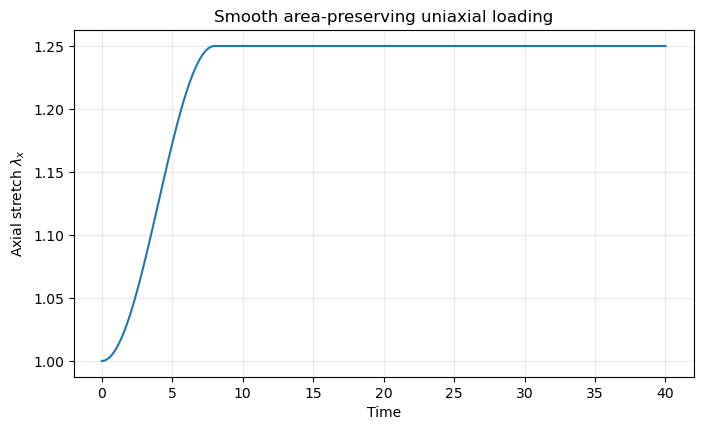

In [7]:
axial_stretch = result.deformation_gradient[:, 0, 0]

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, axial_stretch)
axis.set(
    xlabel="Time",
    ylabel=r"Axial stretch $\lambda_x$",
    title="Smooth area-preserving uniaxial loading",
)
axis.grid(True, alpha=0.25)
plt.show()

### 6.2 Directional mechanical stimulus

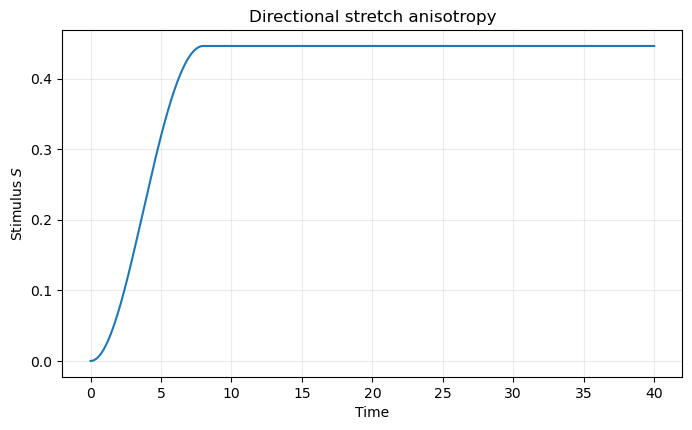

In [8]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.stimulus)
axis.set(
    xlabel="Time",
    ylabel=r"Stimulus $S$",
    title="Directional stretch anisotropy",
)
axis.grid(True, alpha=0.25)
plt.show()

### 6.3 Fiber reorientation

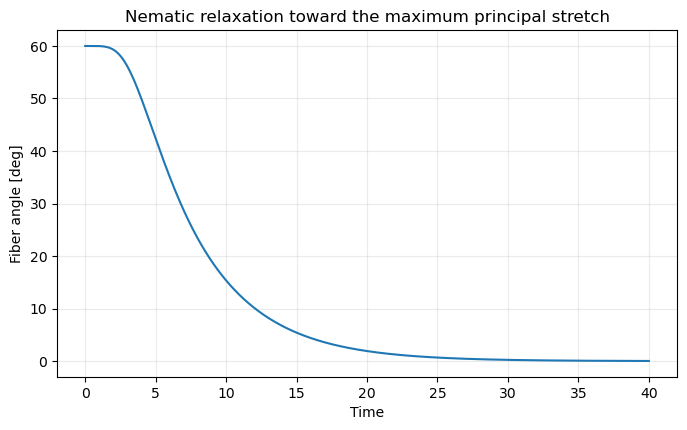

In [9]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.fiber_angle_deg)
axis.set(
    xlabel="Time",
    ylabel="Fiber angle [deg]",
    title="Nematic relaxation toward the maximum principal stretch",
)
axis.grid(True, alpha=0.25)
plt.show()

### 6.4 Structural-order evolution

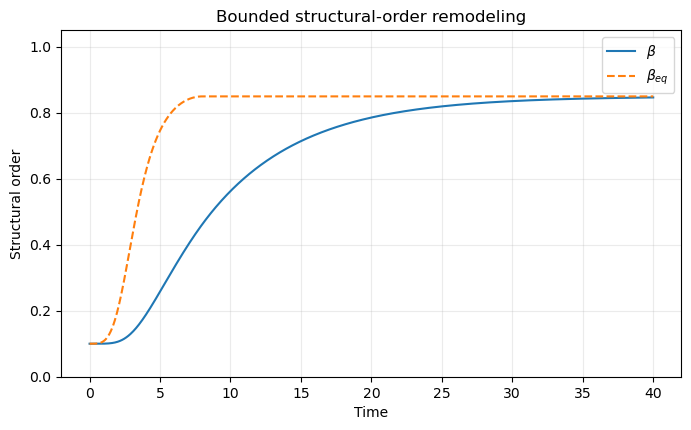

In [10]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.structural_order, label=r"$\beta$")
axis.plot(result.time, result.equilibrium_order, linestyle="--", label=r"$\beta_{eq}$")
axis.set(
    xlabel="Time",
    ylabel="Structural order",
    title="Bounded structural-order remodeling",
    ylim=(0.0, 1.05),
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

### 6.5 Strain-energy history

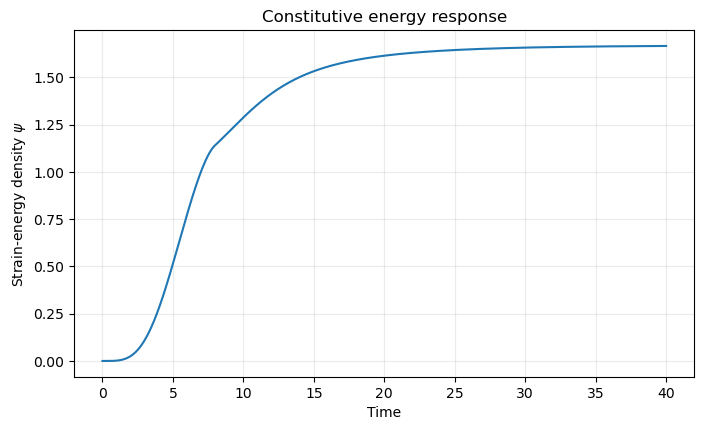

In [11]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.strain_energy)
axis.set(
    xlabel="Time",
    ylabel=r"Strain-energy density $\psi$",
    title="Constitutive energy response",
)
axis.grid(True, alpha=0.25)
plt.show()

### 6.6 Axial Cauchy stress

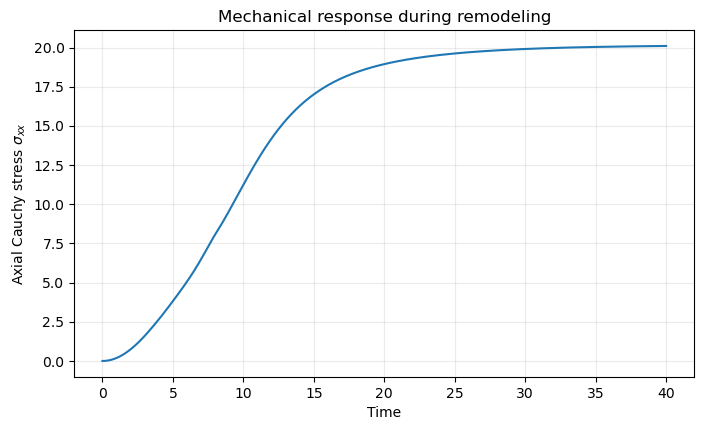

In [12]:
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(result.time, result.cauchy_stress[:, 0, 0])
axis.set(
    xlabel="Time",
    ylabel=r"Axial Cauchy stress $\sigma_{xx}$",
    title="Mechanical response during remodeling",
)
axis.grid(True, alpha=0.25)
plt.show()

### 6.7 Initial and final undirected fiber orientations

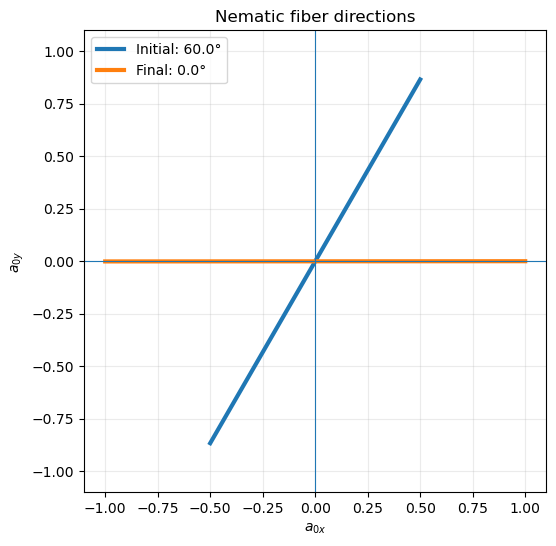

In [13]:
initial_vector = result.fiber_direction[0]
final_vector = result.fiber_direction[-1]

figure, axis = plt.subplots(figsize=(6, 6))
axis.plot(
    [-initial_vector[0], initial_vector[0]],
    [-initial_vector[1], initial_vector[1]],
    linewidth=3,
    label=f"Initial: {initial_angle:.1f}°",
)
axis.plot(
    [-final_vector[0], final_vector[0]],
    [-final_vector[1], final_vector[1]],
    linewidth=3,
    label=f"Final: {final_angle:.1f}°",
)
axis.axhline(0.0, linewidth=0.8)
axis.axvline(0.0, linewidth=0.8)
axis.set(
    xlabel=r"$a_{0x}$",
    ylabel=r"$a_{0y}$",
    title="Nematic fiber directions",
    xlim=(-1.1, 1.1),
    ylim=(-1.1, 1.1),
    aspect="equal",
)
axis.grid(True, alpha=0.25)
axis.legend()
plt.show()

## 7. Physical and numerical sanity checks

The following checks enforce expected properties of the present formulation:

- all deformation gradients preserve orientation, \(J>0\);
- \(\beta\) remains in \([0,1]\);
- all recorded quantities remain finite;
- the fiber rotates toward the tensile axis;
- structural order increases from the selected initial state;
- the Cauchy stress remains symmetric.

In [14]:
determinants = np.linalg.det(result.deformation_gradient)
stress_asymmetry = np.max(
    np.abs(result.cauchy_stress - np.swapaxes(result.cauchy_stress, -1, -2))
)

checks = {
    "positive Jacobian": bool(np.all(determinants > 0.0)),
    "bounded beta": bool(
        np.all((result.structural_order >= 0.0) & (result.structural_order <= 1.0))
    ),
    "finite stress": bool(np.all(np.isfinite(result.cauchy_stress))),
    "finite energy": bool(np.all(np.isfinite(result.strain_energy))),
    "orientation moves toward tensile axis": bool(final_angle < initial_angle),
    "structural order increases": bool(final_beta > initial_beta),
    "symmetric Cauchy stress": bool(stress_asymmetry < 1.0e-10),
}

for name, passed in checks.items():
    print(f"{'PASS' if passed else 'FAIL'} — {name}")

print(f"Maximum stress asymmetry: {stress_asymmetry:.3e}")
assert all(checks.values())

PASS — positive Jacobian
PASS — bounded beta
PASS — finite stress
PASS — finite energy
PASS — orientation moves toward tensile axis
PASS — structural order increases
PASS — symmetric Cauchy stress
Maximum stress asymmetry: 2.220e-16


## 8. Time-step refinement

The internal-variable updates are exact for a fixed target over one time step. During the loading ramp, however, both the stimulus and target direction vary with time. We therefore compare several time steps against the finest result.

In [15]:
time_steps = np.array([0.20, 0.10, 0.05, 0.025], dtype=float)
refinement_rows = []

for dt in time_steps:
    refined_config = SimulationConfig(
        total_time=config.total_time,
        dt=float(dt),
        ramp_duration=config.ramp_duration,
        maximum_stretch=config.maximum_stretch,
        initial_fiber_angle_deg=config.initial_fiber_angle_deg,
        initial_beta=config.initial_beta,
    )
    refined_result = run_homogeneous_remodeling(refined_config, material, remodeling)
    refinement_rows.append(
        (
            float(dt),
            float(refined_result.fiber_angle_deg[-1]),
            float(refined_result.structural_order[-1]),
            float(refined_result.cauchy_stress[-1, 0, 0]),
        )
    )

reference_row = refinement_rows[-1]
header = (
    f"{'dt':>8} {'final angle [deg]':>20} {'final beta':>14} "
    f"{'final sigma_xx':>18} {'angle error':>16}"
)
print(header)
print("-" * len(header))

for dt, angle, beta, stress in refinement_rows:
    angle_error = abs(angle - reference_row[1])
    print(
        f"{dt:8.3f} {angle:20.10f} {beta:14.10f} "
        f"{stress:18.10f} {angle_error:16.3e}"
    )

      dt    final angle [deg]     final beta     final sigma_xx      angle error
--------------------------------------------------------------------------------
   0.200         0.0302437973   0.8462566452      20.0984188628        5.459e-04
   0.100         0.0299306087   0.8462808261      20.0988330751        2.328e-04
   0.050         0.0297752328   0.8462928260      20.0990386285        7.739e-05
   0.025         0.0296978475   0.8462988035      20.0991410195        0.000e+00


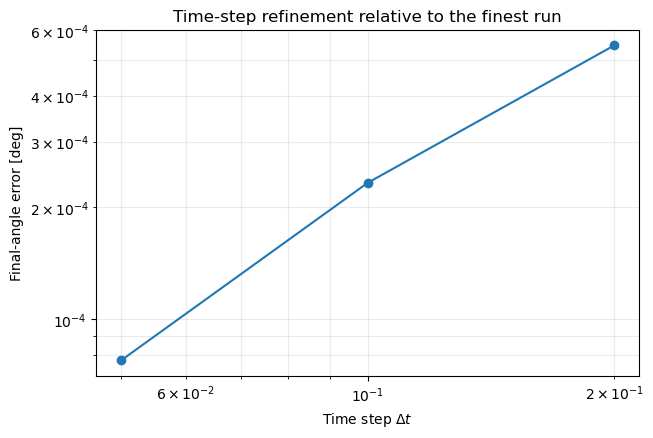

In [16]:
angle_errors = np.array(
    [abs(row[1] - reference_row[1]) for row in refinement_rows[:-1]], dtype=float
)

figure, axis = plt.subplots(figsize=(7, 4.5))
axis.loglog(time_steps[:-1], angle_errors, marker="o")
axis.set(
    xlabel=r"Time step $\Delta t$",
    ylabel="Final-angle error [deg]",
    title="Time-step refinement relative to the finest run",
)
axis.grid(True, which="both", alpha=0.25)
plt.show()

## 9. Export the reproducible time history

The exported CSV contains scalar quantities and all components of the deformation gradient, fiber direction, and Cauchy stress. This format is convenient for regression testing, external visualization, and future parameter-identification workflows.

In [17]:
output_directory = REPOSITORY_ROOT / "results" / "data"
output_directory.mkdir(parents=True, exist_ok=True)
csv_path = output_directory / "homogeneous_remodeling_history.csv"

export_matrix = np.column_stack(
    (
        result.time,
        result.deformation_gradient[:, 0, 0],
        result.deformation_gradient[:, 0, 1],
        result.deformation_gradient[:, 1, 0],
        result.deformation_gradient[:, 1, 1],
        result.fiber_direction[:, 0],
        result.fiber_direction[:, 1],
        result.fiber_angle_deg,
        result.structural_order,
        result.equilibrium_order,
        result.stimulus,
        result.strain_energy,
        result.cauchy_stress[:, 0, 0],
        result.cauchy_stress[:, 0, 1],
        result.cauchy_stress[:, 1, 0],
        result.cauchy_stress[:, 1, 1],
    )
)

header = ",".join(
    (
        "time", "F_11", "F_12", "F_21", "F_22", "a0_x", "a0_y",
        "fiber_angle_deg", "beta", "beta_equilibrium", "stimulus",
        "strain_energy", "sigma_11", "sigma_12", "sigma_21", "sigma_22",
    )
)

np.savetxt(csv_path, export_matrix, delimiter=",", header=header, comments="")
print(f"Saved {export_matrix.shape[0]} rows to:")
print(csv_path.relative_to(REPOSITORY_ROOT))

Saved 801 rows to:
results\data\homogeneous_remodeling_history.csv


## 10. Interpretation

For the selected area-preserving uniaxial extension, the maximum principal stretch is aligned with the \(x\)-axis. The initially oblique fiber family progressively rotates toward that axis. At the same time, the directional-stretch stimulus raises the equilibrium structural order, and \(\beta\) relaxes toward it while remaining bounded.

As the tissue becomes more ordered and its fibers become better aligned with the loading direction, the anisotropic contribution to the axial mechanical response changes. This closes the minimal structure–mechanics–remodeling loop.